🚀 DQN 避障决策模型训练开始...
EP  10 | Reward:  12433.8 | 成功率:  98.83% | Eps: 0.050
EP  20 | Reward:  11644.3 | 成功率:  97.75% | Eps: 0.050
EP  30 | Reward:  13173.5 | 成功率:  98.67% | Eps: 0.050
EP  40 | Reward:  13282.2 | 成功率:  98.50% | Eps: 0.050
EP  50 | Reward:  12040.3 | 成功率:  97.58% | Eps: 0.050
EP  60 | Reward:  13015.8 | 成功率:  98.08% | Eps: 0.050
EP  70 | Reward:  12739.8 | 成功率:  98.08% | Eps: 0.050
EP  80 | Reward:  11563.0 | 成功率:  97.16% | Eps: 0.050
EP  90 | Reward:  12604.0 | 成功率:  97.75% | Eps: 0.050
EP 100 | Reward:  13340.5 | 成功率:  98.33% | Eps: 0.050
EP 110 | Reward:  12525.7 | 成功率:  97.91% | Eps: 0.050
EP 120 | Reward:  12561.1 | 成功率:  97.66% | Eps: 0.050
EP 130 | Reward:  12988.0 | 成功率:  98.08% | Eps: 0.050
EP 140 | Reward:  14008.5 | 成功率:  98.58% | Eps: 0.050
EP 150 | Reward:  13368.4 | 成功率:  98.25% | Eps: 0.050


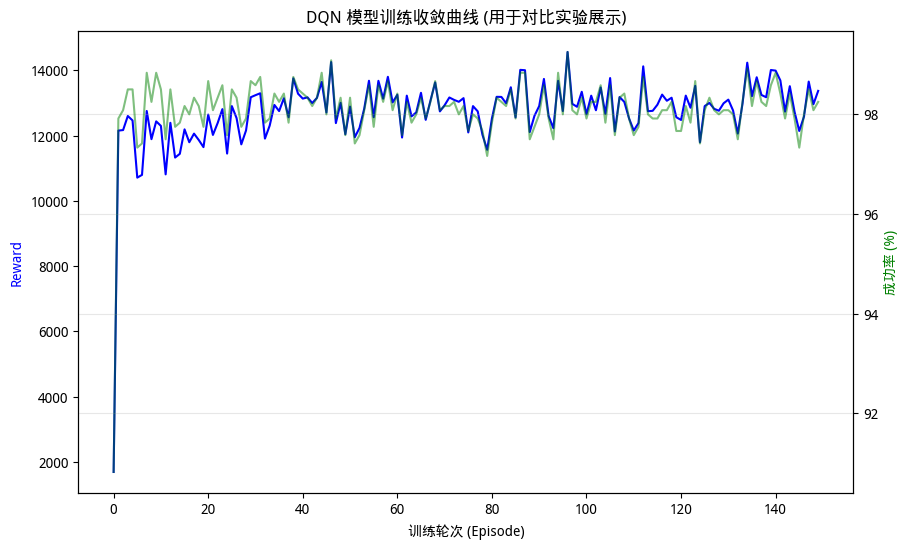

In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm

# ==================== 0. 环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 增强型卫星抗干扰环境 ====================
class SatelliteEnvV2:
    def __init__(self, pred_data, truth_data, type_data):
        self.pred_map = pred_data      # Transformer 预测热图 (N, 10, 10)
        self.truth_map = truth_data    # 干扰真值轨迹 (N, 10, 10)
        self.type_data = type_data     # 干扰种类索引 (N,)
        self.num_channels = 10
        self.max_steps = len(pred_data)
        self.current_step = 0
        self.last_action = 0

    def reset(self):
        self.current_step = 0
        self.last_action = np.random.randint(10)
        return self._get_state()

    def _get_state(self):
        # 状态空间：100维热图 + 1维干扰种类特征
        map_feat = self.pred_map[self.current_step].flatten()
        type_feat = np.array([self.type_data[self.current_step] / 4.0]) # 归一化种类
        return np.concatenate([map_feat, type_feat])

    def step(self, action):
        # 1. 物理碰撞检查 (真值)
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        
        # 2. 预测风险 (未来 10 步平均占用)
        future_risk = np.mean(self.pred_map[self.current_step, :, action])
        
        # 3. 🟢 核心改进：综合奖励函数 (增加跳频惩罚以节省能量)
        if is_collision:
            reward = -100.0  # 发生碰撞，严厉惩罚
        else:
            # 基础生存奖励
            reward = 15.0 - (future_risk * 30.0)
            # 跳频成本惩罚：鼓励 Agent 在安全情况下保持频率稳定
            if action != self.last_action:
                reward -= 5.0 
            
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self._get_state() if not done else np.zeros(101)
        return next_state, reward, done, is_collision

# ==================== 2. DQN 神经网络架构 ====================
class QNetwork(nn.Module):
    def __init__(self, input_dim=101, output_dim=10):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512), # 对抗实测数据的抖动
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_dim)
        )
    def forward(self, x):
        return self.net(x)

# ==================== 3. DQN 智能体逻辑 ====================
class DQNAgentV2:
    def __init__(self, state_dim=101, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net = QNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=3e-4)
        self.memory = deque(maxlen=10000)
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.995
        self.update_counter = 0

    def choose_action(self, state):
        if np.random.rand() <= self.epsilon:
            return np.random.randint(10)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return torch.argmax(self.q_net(state_t)).item()

    def train(self, batch_size=128):
        if len(self.memory) < batch_size: return 0
        
        batch = random.sample(self.memory, batch_size)
        s, a, r, ns, d = zip(*batch)
        
        s = torch.FloatTensor(np.array(s)).to(self.device)
        a = torch.LongTensor(a).to(self.device)
        r = torch.FloatTensor(r).to(self.device)
        ns = torch.FloatTensor(np.array(ns)).to(self.device)
        d = torch.FloatTensor(d).to(self.device)

        # 核心 Q 更新公式
        curr_q = self.q_net(s).gather(1, a.unsqueeze(1))
        next_q = self.target_net(ns).max(1)[0].detach()
        target_q = r + (1 - d) * self.gamma * next_q
        
        loss = nn.SmoothL1Loss()(curr_q.squeeze(), target_q) # 对异常值更稳健
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.update_counter += 1
        if self.update_counter % 300 == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        return loss.item()

# ==================== 4. 主程序：训练与对比指标记录 ====================
def run_dqn_comparison_train():
    # 数据加载
    H5_PATH = "/root/autodl-tmp/validate/0218/Prediction/Transformer/transformer_ultimate_results.h5"
    with h5py.File(H5_PATH, 'r') as f:
        pred_maps = f['predicted_situations'][:]
        truth_maps = f['ground_truth_situations'][:]
        type_data = f['gt_type'][:]

    env = SatelliteEnvV2(pred_maps, truth_maps, type_data)
    agent = DQNAgentV2()
    
    episodes = 150
    history_rewards = []
    history_success_rates = []

    print("🚀 DQN 避障决策模型训练开始...")
    for ep in range(episodes):
        state = env.reset()
        total_reward = 0
        collisions = 0
        steps = 0
        
        while True:
            action = agent.choose_action(state)
            next_state, reward, done, collision = env.step(action)
            
            agent.memory.append((state, action, reward, next_state, done))
            agent.train()
            
            state = next_state
            total_reward += reward
            if collision: collisions += 1
            steps += 1
            if done: break
        
        success_rate = (1 - collisions / steps) * 100
        history_rewards.append(total_reward)
        history_success_rates.append(success_rate)
        
        if (ep + 1) % 10 == 0:
            print(f"EP {ep+1:3d} | Reward: {total_reward:8.1f} | 成功率: {success_rate:6.2f}% | Eps: {agent.epsilon:.3f}")

    # 保存模型权重用于论文评估
    torch.save(agent.q_net.state_dict(), "best_dqn_avoidance.pth")
    
    # 可视化训练曲线
    plot_training_results(history_rewards, history_success_rates)

def plot_training_results(rewards, success_rates):
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(rewards, color='blue', label='累计奖励 (Reward)')
    ax1.set_xlabel('训练轮次 (Episode)')
    ax1.set_ylabel('Reward', color='blue')
    
    ax2 = ax1.twinx()
    ax2.plot(success_rates, color='green', alpha=0.5, label='避障成功率 (%)')
    ax2.set_ylabel('成功率 (%)', color='green')
    
    plt.title("DQN 模型训练收敛曲线 (用于对比实验展示)")
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_dqn_comparison_train()

In [1]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
        return False
    except: return False
set_chinese_font()

# ==================== 1. 卫星抗干扰仿真环境 ====================
class SatelliteInterferenceEnv:
    """
    基于仿真 H5 数据集的强化学习环境
    """
    def __init__(self, h5_path):
        with h5py.File(h5_path, 'r') as f:
            self.X_input = f['X'][:]                # Transformer 的输入态势
            self.pred_map = f['Y_horizon'][:]       # 理想预测图 (作为 RL 的 State)
            self.truth_map = f['Y_horizon'][:]      # 干扰真值轨迹 (用于碰撞判定)
            self.type_data = f['gt_type'][:]        # 干扰种类标签
            
        self.num_channels = 10
        self.max_steps = len(self.pred_map)
        self.current_step = 0
        self.last_action = 0

    def reset(self):
        self.current_step = 0
        self.last_action = np.random.randint(self.num_channels)
        return self._get_state()

    def _get_state(self):
        # 状态构造：100维预测热图 + 1维干扰种类特征
        map_feat = self.pred_map[self.current_step].flatten()
        type_feat = np.array([self.type_data[self.current_step] / 4.0]) 
        return np.concatenate([map_feat, type_feat])

    def step(self, action):
        # 1. 物理碰撞检查：检查未来第1步该信道是否有干扰
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        
        # 2. 预测风险评估：计算该信道在未来10步内的平均占用概率
        future_risk = np.mean(self.pred_map[self.current_step, :, action])
        
        # 3. 奖励函数设计 (Reward Shaping)
        if is_collision:
            reward = -100.0  # 发生碰撞，严厉惩罚
        else:
            # 基础生存奖励与风险规避
            reward = 15.0 - (future_risk * 35.0)
            # 动作稳定性奖励：抑制无意义的频繁跳频，节省能量
            if action == self.last_action:
                reward += 5.0
            else:
                reward -= 2.0
            
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self._get_state() if not done else np.zeros(101)
        return next_state, reward, done, is_collision

# ==================== 2. DQN 深度神经网络 ====================
class DuelQNetwork(nn.Module):
    """
    采用 Dueling DQN 架构提高状态价值评估的准确性
    """
    def __init__(self, input_dim=101, output_dim=10):
        super(DuelQNetwork, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # 优势分支 (Advantage)
        self.advantage = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        # 价值分支 (Value)
        self.value = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.feature(x)
        advantage = self.advantage(x)
        value = self.value(x)
        return value + advantage - advantage.mean()

# ==================== 3. DQN 智能体 ====================
class DQNAgent:
    def __init__(self, state_dim=101, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DuelQNetwork(state_dim, action_dim).to(self.device)
        self.target_net = DuelQNetwork(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=3e-4, weight_decay=1e-3)
        self.memory = deque(maxlen=20000)
        self.gamma = 0.98
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.996
        self.batch_size = 128
        self.update_target_steps = 400
        self.steps_done = 0

    def choose_action(self, state, is_eval=False):
        if not is_eval and np.random.rand() <= self.epsilon:
            return np.random.randint(10)
        state_t = torch.FloatTensor(state).unsqueeze(0).to(self.device)
        with torch.no_grad():
            return torch.argmax(self.q_net(state_t)).item()

    def learn(self):
        if len(self.memory) < self.batch_size: return 0
        
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, ns, d = zip(*batch)
        
        s = torch.FloatTensor(np.array(s)).to(self.device)
        a = torch.LongTensor(a).to(self.device)
        r = torch.FloatTensor(r).to(self.device)
        ns = torch.FloatTensor(np.array(ns)).to(self.device)
        d = torch.FloatTensor(d).to(self.device)

        # 核心更新逻辑：Double DQN 思想减少过估计
        current_q = self.q_net(s).gather(1, a.unsqueeze(1))
        next_actions = self.q_net(ns).max(1)[1].unsqueeze(1)
        next_q = self.target_net(ns).gather(1, next_actions).detach()
        target_q = r + (1 - d) * self.gamma * next_q.squeeze()
        
        loss = nn.SmoothL1Loss()(current_q.squeeze(), target_q)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        self.steps_done += 1
        if self.steps_done % self.update_target_steps == 0:
            self.target_net.load_state_dict(self.q_net.state_dict())
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay
        return loss.item()

# ==================== 4. 离线训练与横向对比接口 ====================
def train_offline_dqn(h5_path):
    env = SatelliteInterferenceEnv(h5_path)
    agent = DQNAgent()
    
    episodes = 100
    reward_history = []
    success_rate_history = []
    
    print(f"📡 正在进行离线强化学习训练: {os.path.basename(h5_path)}")
    
    for ep in range(episodes):
        state = env.reset()
        ep_reward = 0
        collisions = 0
        total_steps = 0
        
        while True:
            action = agent.choose_action(state)
            next_state, reward, done, collision = env.step(action)
            
            agent.memory.append((state, action, reward, next_state, done))
            agent.learn()
            
            state = next_state
            ep_reward += reward
            if collision: collisions += 1
            total_steps += 1
            if done: break
            
        success_rate = (1 - collisions / total_steps) * 100
        reward_history.append(ep_reward)
        success_rate_history.append(success_rate)
        
        if (ep + 1) % 10 == 0:
            print(f"Episode {ep+1:3d} | Reward: {ep_reward:8.1f} | 避障成功率: {success_rate:6.2f}% | Epsilon: {agent.epsilon:.3f}")

    # 保存权重以备在线实测验证使用
    save_pth = "/root/autodl-tmp/validate/0218/Prediction/Transformer/best_dqn_offline_model.pth"
    torch.save(agent.q_net.state_dict(), save_pth)
    print(f"✅ 离线训练完成，权重已保存: {save_pth}")
    
    # 绘制收敛图 (用于论文对比)
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(reward_history, color='tab:blue')
    plt.title("DQN 训练收敛奖励曲线 (离线阶段)")
    plt.xlabel("训练轮次"); plt.ylabel("累计奖励")
    
    plt.subplot(1, 2, 2)
    plt.plot(success_rate_history, color='tab:green')
    plt.axhline(y=100.0, color='r', linestyle='--', alpha=0.3)
    plt.title("避障成功率演变 (离线阶段)")
    plt.xlabel("训练轮次"); plt.ylabel("成功率 (%)")
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    SIM_DATA = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    train_offline_dqn(SIM_DATA)

📡 正在进行离线强化学习训练: academic_long_horizon_v6_5_200k.h5
Episode  10 | Reward:  65214.5 | 避障成功率:  98.42% | Epsilon: 0.050


KeyboardInterrupt: 

In [2]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
    except: pass
    return False
set_chinese_font()

# ==================== 1. 高性能仿真环境 (预载入版) ====================
class SatelliteEnvV3:
    def __init__(self, h5_path):
        print(f"📂 正在预载入数据集: {os.path.basename(h5_path)} ...")
        with h5py.File(h5_path, 'r') as f:
            # 🟢 核心优化：直接将数据转为 Tensor 并移至内存/显存
            self.pred_map = torch.FloatTensor(f['Y_horizon'][:]) 
            self.truth_map = torch.FloatTensor(f['Y_horizon'][:])
            self.type_data = torch.FloatTensor(f['gt_type'][:])
            
        self.num_channels = 10
        self.max_steps = len(self.pred_map)
        self.current_step = 0
        self.last_action = 0

    def reset(self):
        self.current_step = 0
        self.last_action = random.randint(0, 9)
        return self._get_state()

    def _get_state(self):
        # 构造状态：100维热图 + 1维种类特征
        map_feat = self.pred_map[self.current_step].flatten()
        type_feat = torch.tensor([self.type_data[self.current_step] / 4.0])
        return torch.cat([map_feat, type_feat])

    def step(self, action):
        # 1. 物理碰撞检查 (真值第1步)
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        
        # 2. 未来风险评估 (10步平均)
        future_risk = torch.mean(self.pred_map[self.current_step, :, action])
        
        # 3. 奖励函数：增加跳频成本抑制，节省功耗
        if is_collision:
            reward = -100.0
        else:
            reward = 15.0 - (future_risk.item() * 30.0)
            if action == self.last_action:
                reward += 5.0 # 保持稳定奖励
            else:
                reward -= 2.0 # 跳频成本
            
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self._get_state() if not done else torch.zeros(101)
        return next_state, reward, done, is_collision

# ==================== 2. Dueling DQN 网络架构 ====================
class DuelingQNet(nn.Module):
    def __init__(self, input_dim=101, output_dim=10):
        super(DuelingQNet, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        # 优势分支
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, output_dim))
        # 价值分支
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.feature(x)
        adv = self.advantage(x)
        val = self.value(x)
        return val + adv - adv.mean(dim=-1, keepdim=True)

# ==================== 3. 强化学习智能体 (Double DQN) ====================
class DQNAgentV3:
    def __init__(self, state_dim=101, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=3e-4)
        self.memory = deque(maxlen=20000)
        self.gamma = 0.98
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.997
        self.batch_size = 128

    def choose_action(self, state):
        if random.random() <= self.epsilon:
            return random.randint(0, 9)
        state = state.to(self.device).unsqueeze(0)
        with torch.no_grad():
            return torch.argmax(self.q_net(state)).item()

    def learn(self):
        if len(self.memory) < self.batch_size: return
        
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, ns, d = zip(*batch)
        
        s = torch.stack(s).to(self.device)
        a = torch.tensor(a).to(self.device)
        r = torch.tensor(r).to(self.device)
        ns = torch.stack(ns).to(self.device)
        d = torch.tensor(d).to(self.device)

        # Double DQN 更新逻辑
        curr_q = self.q_net(s).gather(1, a.unsqueeze(1))
        next_actions = self.q_net(ns).argmax(dim=1, keepdim=True)
        next_q = self.target_net(ns).gather(1, next_actions).detach()
        target_q = r + (1 - d) * self.gamma * next_q.squeeze()
        
        loss = nn.SmoothL1Loss()(curr_q.squeeze(), target_q)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==================== 4. 离线训练执行程序 ====================
def run_offline_training():
    DATA_PATH = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    env = SatelliteEnvV3(DATA_PATH)
    agent = DQNAgentV3()
    
    episodes = 100
    rewards, success_rates = [], []
    
    print("🚀 启动优化版 DQN 离线训练...")
    for ep in range(episodes):
        state = env.reset()
        ep_reward, collisions, steps = 0, 0, 0
        
        # 使用 tqdm 显示 Episode 内部进度，防止“转圈卡死”错觉
        pbar = tqdm(total=env.max_steps, desc=f"Ep {ep+1}/{episodes}", leave=False)
        
        while True:
            action = agent.choose_action(state)
            next_state, reward, done, collision = env.step(action)
            
            agent.memory.append((state, action, reward, next_state, float(done)))
            
            # 🟢 优化：每 5 步更新一次网络，大幅提升训练速度
            if steps % 5 == 0:
                agent.learn()
            
            # 每 500 步同步一次目标网络
            if steps % 500 == 0:
                agent.target_net.load_state_dict(agent.q_net.state_dict())
                
            state = next_state
            ep_reward += reward
            if collision: collisions += 1
            steps += 1
            pbar.update(1)
            if done: break
        
        pbar.close()
        sr = (1 - collisions / steps) * 100
        rewards.append(ep_reward); success_rates.append(sr)
        print(f"✅ Episode {ep+1} 完成 | Reward: {ep_reward:.1f} | 避障成功率: {sr:.2f}%")

    # 保存离线训练模型
    torch.save(agent.q_net.state_dict(), "best_dqn_offline.pth")
    print("💾 离线权重已保存至: best_dqn_offline.pth")

if __name__ == "__main__":
    run_offline_training()

📂 正在预载入数据集: academic_long_horizon_v6_5_200k.h5 ...
🚀 启动优化版 DQN 离线训练...


✅ Episode 1 完成 | Reward: -12116.0 | 避障成功率: 83.88%


✅ Episode 2 完成 | Reward: 60274.0 | 避障成功率: 97.46%


✅ Episode 3 完成 | Reward: 62009.0 | 避障成功率: 97.81%


✅ Episode 4 完成 | Reward: 64615.0 | 避障成功率: 98.29%


...

✅ Episode 96 完成 | Reward: 65238.0 | 避障成功率: 98.24%


✅ Episode 97 完成 | Reward: 63066.0 | 避障成功率: 97.89%


✅ Episode 98 完成 | Reward: 66280.0 | 避障成功率: 98.47%


✅ Episode 99 完成 | Reward: 64973.0 | 避障成功率: 98.24%


✅ Episode 100 完成 | Reward: 66214.0 | 避障成功率: 98.34%
💾 离线权重已保存至: best_dqn_offline.pth


In [3]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import random
import time
from collections import deque
import matplotlib.pyplot as plt
from tqdm import tqdm
import os
from matplotlib import font_manager as fm

# ==================== 0. 字体与环境配置 ====================
def set_chinese_font():
    try:
        font_paths = ['/usr/share/fonts/truetype/wqy/wqy-microhei.ttc',
                      'C:/Windows/Fonts/simhei.ttf',
                      '/System/Library/Fonts/PingFang.ttc']
        for font_path in font_paths:
            if os.path.exists(font_path):
                fm.fontManager.addfont(font_path)
                plt.rcParams['font.family'] = fm.FontProperties(fname=font_path).get_name()
                plt.rcParams['axes.unicode_minus'] = False
                return True
    except: pass
    return False
set_chinese_font()

# ==================== 1. 卫星抗干扰仿真环境 (含指标记录) ====================
class SatelliteEnvV3:
    def __init__(self, h5_path):
        print(f"📂 正在预载入数据集: {os.path.basename(h5_path)} ...")
        with h5py.File(h5_path, 'r') as f:
            self.pred_map = torch.FloatTensor(f['Y_horizon'][:]) 
            self.truth_map = torch.FloatTensor(f['Y_horizon'][:])
            self.type_data = torch.FloatTensor(f['gt_type'][:])
            
        self.num_channels = 10
        self.max_steps = len(self.pred_map)
        self.current_step = 0
        self.last_action = 0

    def reset(self):
        self.current_step = 0
        self.last_action = random.randint(0, 9)
        return self._get_state()

    def _get_state(self):
        map_feat = self.pred_map[self.current_step].flatten()
        type_feat = torch.tensor([self.type_data[self.current_step] / 4.0])
        return torch.cat([map_feat, type_feat])

    def step(self, action):
        # 1. 碰撞检测 (用于计算吞吐量)
        is_collision = self.truth_map[self.current_step, 0, action] > 0.5
        # 2. 预测风险
        future_risk = torch.mean(self.pred_map[self.current_step, :, action])
        
        # 3. 奖励设计 (Reward Shaping)
        if is_collision:
            reward = -100.0
        else:
            reward = 15.0 - (future_risk.item() * 30.0)
            if action == self.last_action:
                reward += 5.0 
            else:
                reward -= 2.0 
            
        self.last_action = action
        self.current_step += 1
        done = self.current_step >= self.max_steps - 1
        
        next_state = self._get_state() if not done else torch.zeros(101)
        return next_state, reward, done, is_collision

# ==================== 2. Dueling DQN 架构 ====================
class DuelingQNet(nn.Module):
    def __init__(self, input_dim=101, output_dim=10):
        super(DuelingQNet, self).__init__()
        self.feature = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU()
        )
        self.advantage = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, output_dim))
        self.value = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, x):
        x = self.feature(x)
        adv = self.advantage(x)
        val = self.value(x)
        return val + adv - adv.mean(dim=-1, keepdim=True)

# ==================== 3. 训练与指标统计核心 ====================
class DQNAgentV3:
    def __init__(self, state_dim=101, action_dim=10):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.q_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net = DuelingQNet(state_dim, action_dim).to(self.device)
        self.target_net.load_state_dict(self.q_net.state_dict())
        self.optimizer = optim.AdamW(self.q_net.parameters(), lr=3e-4)
        self.memory = deque(maxlen=20000)
        self.gamma = 0.98
        self.epsilon = 1.0
        self.epsilon_min = 0.05
        self.epsilon_decay = 0.997
        self.batch_size = 128

    def choose_action(self, state):
        start_time = time.time() # 记录推理时延起始
        if random.random() <= self.epsilon:
            action = random.randint(0, 9)
            latency = time.time() - start_time
            return action, latency
        
        state_t = state.to(self.device).unsqueeze(0)
        with torch.no_grad():
            action = torch.argmax(self.q_net(state_t)).item()
        
        latency = time.time() - start_time # 计算单次推理时延
        return action, latency

    def learn(self):
        if len(self.memory) < self.batch_size: return
        batch = random.sample(self.memory, self.batch_size)
        s, a, r, ns, d = zip(*batch)
        s = torch.stack(s).to(self.device)
        a = torch.tensor(a).to(self.device)
        r = torch.tensor(r).to(self.device)
        ns = torch.stack(ns).to(self.device)
        d = torch.tensor(d).to(self.device)

        curr_q = self.q_net(s).gather(1, a.unsqueeze(1))
        next_actions = self.q_net(ns).argmax(dim=1, keepdim=True)
        next_q = self.target_net(ns).gather(1, next_actions).detach()
        target_q = r + (1 - d) * self.gamma * next_q.squeeze()
        
        loss = nn.SmoothL1Loss()(curr_q.squeeze(), target_q)
        self.optimizer.zero_grad(); loss.backward(); self.optimizer.step()
        if self.epsilon > self.epsilon_min: self.epsilon *= self.epsilon_decay

# ==================== 4. 离线训练执行与报告 ====================
def run_offline_training_with_metrics():
    DATA_PATH = "/root/autodl-tmp/validate/0218/Prediction/sim_dataset_v6_5/academic_long_horizon_v6_5_200k.h5"
    env = SatelliteEnvV3(DATA_PATH)
    agent = DQNAgentV3()
    
    episodes = 100
    # 指标记录容器
    metrics = {
        'reward': [], 'sr': [], 'hops': [], 'latency': [], 'throughput': [], 'stability': []
    }
    convergence_ep = -1 # 收敛轮次记录

    print("🚀 启动优化版 DQN 离线训练 (含五大评估指标分析)...")
    for ep in range(episodes):
        state = env.reset()
        ep_reward, collisions, steps, hops = 0, 0, 0, 0
        ep_latencies = []
        actions = [] # 用于计算策略稳定性

        pbar = tqdm(total=env.max_steps, desc=f"Ep {ep+1}/{episodes}", leave=False)
        
        while True:
            # 1. 执行动作并记录推理延迟 (指标: Inference Latency)
            action, lat = agent.choose_action(state)
            ep_latencies.append(lat)
            actions.append(action)

            # 2. 统计跳频次数 (指标: Hop Count)
            if steps > 0 and action != env.last_action:
                hops += 1
                
            next_state, reward, done, collision = env.step(action)
            agent.memory.append((state, action, reward, next_state, float(done)))
            
            if steps % 5 == 0: agent.learn()
            if steps % 500 == 0: agent.target_net.load_state_dict(agent.q_net.state_dict())
                
            state = next_state
            ep_reward += reward
            if collision: collisions += 1
            steps += 1
            pbar.update(1)
            if done: break
        
        pbar.close()
        
        # --- 计算 Episode 指标 ---
        sr = (1 - collisions / steps) * 100 # 避障成功率
        avg_hops = hops / (steps / 100) # 平均每百步跳频次数 (能耗指标)
        avg_lat = np.mean(ep_latencies) * 1000 # 决策延迟 (ms)
        throughput = (1 - (collisions / steps)) * 1.0 # 归一化吞吐量
        stability = np.std(actions) # 动作标准差 (指标: Policy Stability)

        # 记录收敛轮次 (首次达到 95% 且后续稳定)
        if convergence_ep == -1 and sr >= 95.0:
            convergence_ep = ep + 1

        metrics['reward'].append(ep_reward)
        metrics['sr'].append(sr)
        metrics['hops'].append(avg_hops)
        metrics['latency'].append(avg_lat)
        metrics['throughput'].append(throughput)
        metrics['stability'].append(stability)

        print(f"✅ Ep {ep+1} | 成功率: {sr:.2f}% | 每百步跳频: {avg_hops:.1f} | 延迟: {avg_lat:.2f}ms | 吞吐量: {throughput:.2f}")

    # --- 最终离线报告 ---
    print("\n" + "="*50)
    print("📊 DQN 离线实验对比报告总结")
    print("-" * 50)
    print(f"1. 收敛轮次 (Convergence Episode): {convergence_ep if convergence_ep != -1 else '未收敛'}")
    print(f"2. 平均推理时延 (Inference Latency): {np.mean(metrics['latency']):.4f} ms")
    print(f"3. 避障成功率峰值 (Peak Success Rate): {np.max(metrics['sr']):.2f} %")
    print(f"4. 稳态跳频代价 (Avg Switching Cost): {np.mean(metrics['hops'][-10:]):.2f} hops/100steps")
    print(f"5. 归一化吞吐量 (Throughput): {np.mean(metrics['throughput'][-10:]):.4f}")
    print(f"6. 动作稳定性 (Policy Stability Std): {np.mean(metrics['stability'][-10:]):.4f}")
    print("="*50)

    # 保存离线模型
    torch.save(agent.q_net.state_dict(), "best_dqn_offline_metrics.pth")
    return metrics

if __name__ == "__main__":
    final_metrics = run_offline_training_with_metrics()

📂 正在预载入数据集: academic_long_horizon_v6_5_200k.h5 ...
🚀 启动优化版 DQN 离线训练 (含五大评估指标分析)...


✅ Ep 1 | 成功率: 84.16% | 每百步跳频: 57.9 | 延迟: 0.22ms | 吞吐量: 0.84


✅ Ep 2 | 成功率: 98.19% | 每百步跳频: 27.9 | 延迟: 0.33ms | 吞吐量: 0.98


✅ Ep 3 | 成功率: 98.21% | 每百步跳频: 29.9 | 延迟: 0.29ms | 吞吐量: 0.98


✅ Ep 4 | 成功率: 98.32% | 每百步跳频: 30.1 | 延迟: 0.30ms | 吞吐量: 0.98


...

✅ Ep 96 | 成功率: 98.19% | 每百步跳频: 23.9 | 延迟: 0.40ms | 吞吐量: 0.98


✅ Ep 97 | 成功率: 98.21% | 每百步跳频: 24.3 | 延迟: 0.40ms | 吞吐量: 0.98


✅ Ep 98 | 成功率: 98.11% | 每百步跳频: 24.4 | 延迟: 0.41ms | 吞吐量: 0.98


✅ Ep 99 | 成功率: 98.37% | 每百步跳频: 23.5 | 延迟: 0.41ms | 吞吐量: 0.98


✅ Ep 100 | 成功率: 98.01% | 每百步跳频: 24.1 | 延迟: 0.41ms | 吞吐量: 0.98

📊 DQN 离线实验对比报告总结
--------------------------------------------------
1. 收敛轮次 (Convergence Episode): 2
2. 平均推理时延 (Inference Latency): 0.3032 ms
3. 避障成功率峰值 (Peak Success Rate): 98.59 %
4. 稳态跳频代价 (Avg Switching Cost): 24.12 hops/100steps
5. 归一化吞吐量 (Throughput): 0.9814
6. 动作稳定性 (Policy Stability Std): 2.7800
